# 🏠 House Price Prediction Using Multiple Linear Regression

## 1. Business Problem

A real estate company wants to estimate house prices based on different property characteristics.

The goal of this project is to build a Machine Learning model that can predict the price of a house using multiple features such as area, number of bedrooms, number of bathrooms, house age, and parking availability.

### Objective

- Understand the factors that may influence house prices.
- Analyze relationships between house features and price.
- Build a Multiple Linear Regression model.
- Evaluate the model's prediction performance.
- Predict the price of a new house.

In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Create Dataset

In [59]:
houses = pd.DataFrame({
    "Area": [800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600,
             2800, 3000, 3200, 3400, 3600, 3800, 4000, 4200, 4500, 4800],

    "Bedrooms": [1, 2, 2, 2, 3, 3, 3, 4, 3, 4,
                 4, 4, 5, 5, 5, 5, 6, 6, 6, 7],

    "Bathrooms": [1, 1, 2, 2, 2, 2, 3, 3, 3, 3,
                  3, 4, 4, 4, 4, 5, 5, 5, 6, 6],

    "Age": [20, 15, 12, 10, 8, 7, 6, 5, 8, 4,
            6, 3, 2, 4, 3, 2, 5, 2, 1, 1],

    "Parking": [0, 1, 1, 1, 1, 2, 2, 2, 2, 2,
                2, 2, 3, 3, 3, 3, 3, 3, 4, 4],

    "Price": [2800000, 3500000, 4300000, 4800000, 5600000,
              6200000, 7000000, 7800000, 8200000, 9000000,
              9500000, 10500000, 11500000, 12200000, 13000000,
              14000000, 15000000, 16000000, 17500000, 19000000]
})

print(houses)

    Area  Bedrooms  Bathrooms  Age  Parking     Price
0    800         1          1   20        0   2800000
1   1000         2          1   15        1   3500000
2   1200         2          2   12        1   4300000
3   1400         2          2   10        1   4800000
4   1600         3          2    8        1   5600000
5   1800         3          2    7        2   6200000
6   2000         3          3    6        2   7000000
7   2200         4          3    5        2   7800000
8   2400         3          3    8        2   8200000
9   2600         4          3    4        2   9000000
10  2800         4          3    6        2   9500000
11  3000         4          4    3        2  10500000
12  3200         5          4    2        3  11500000
13  3400         5          4    4        3  12200000
14  3600         5          4    3        3  13000000
15  3800         5          5    2        3  14000000
16  4000         6          5    5        3  15000000
17  4200         6          

## 3. Data Understanding

In [60]:
print("First 5 rows:")
print(houses.head())

print("\nDataset Shape:")
print(houses.shape)

print("\nDataset Information:")
houses.info()

print("\nStatistical Summary:")
print(houses.describe())

First 5 rows:
   Area  Bedrooms  Bathrooms  Age  Parking    Price
0   800         1          1   20        0  2800000
1  1000         2          1   15        1  3500000
2  1200         2          2   12        1  4300000
3  1400         2          2   10        1  4800000
4  1600         3          2    8        1  5600000

Dataset Shape:
(20, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area       20 non-null     int64
 1   Bedrooms   20 non-null     int64
 2   Bathrooms  20 non-null     int64
 3   Age        20 non-null     int64
 4   Parking    20 non-null     int64
 5   Price      20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB

Statistical Summary:
              Area   Bedrooms  Bathrooms        Age    Parking         Price
count    20.000000  20.000000  20.000000  20.000000  20.000000  2.000000e+01
mean   2

### Observation

The dataset contains 20 houses and 6 columns: Area, Bedrooms, Bathrooms, Age, Parking, and Price.

The dataset contains numerical features that can be used to predict house prices. The average house price is approximately ₹9.94 million.

## 4. Data Cleaning

In [61]:
print("Missing values:")
print(houses.isna().sum())

print("\nDuplicate rows:")
print(houses.duplicated().sum())

Missing values:
Area         0
Bedrooms     0
Bathrooms    0
Age          0
Parking      0
Price        0
dtype: int64

Duplicate rows:
0


### Observation

The dataset contains no missing values and no duplicate rows. Therefore, no additional data cleaning or imputation is required.

## 5. Exploratory Data Analysis

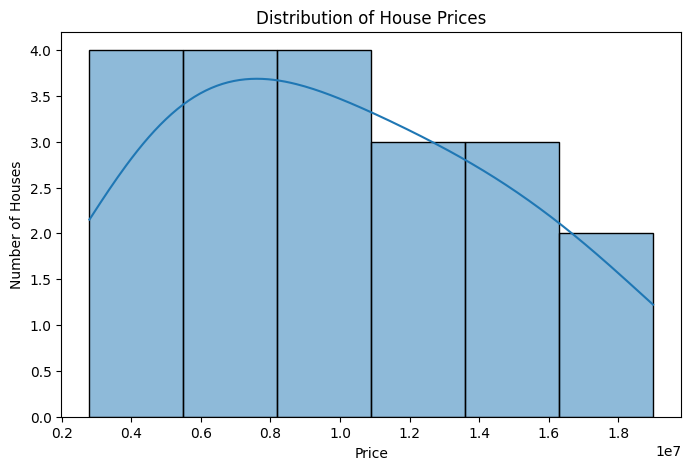

In [62]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=houses,
    x="Price",
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show()

### Observation

The distribution shows how house prices are spread across the dataset. Most houses fall within the middle-to-higher price range, while the dataset also contains some lower-priced properties.

## 6. Feature vs Price Analysis

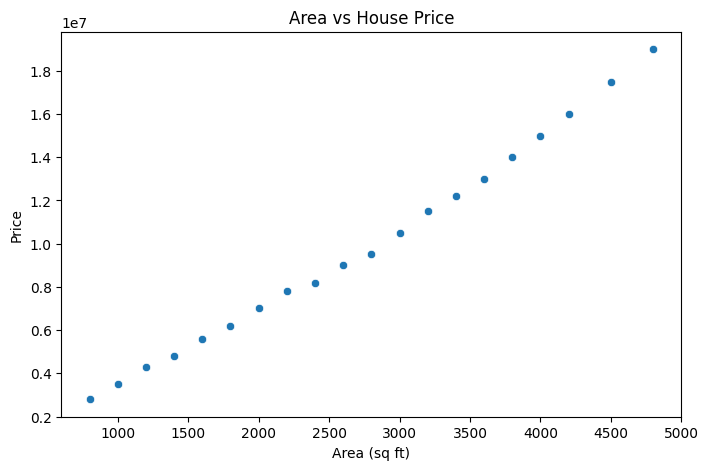

In [63]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Area",
    y="Price",
    data=houses
)

plt.title("Area vs House Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")

plt.show()

### Observation

The scatter plot shows a strong positive relationship between area and house price. In general, houses with larger areas tend to have higher prices.

## 7. Correlation Analysis

In [64]:
correlation = houses.corr(numeric_only=True)

print(correlation)

               Area  Bedrooms  Bathrooms       Age   Parking     Price
Area       1.000000  0.977282   0.980260 -0.858816  0.954112  0.996201
Bedrooms   0.977282  1.000000   0.951143 -0.873942  0.952157  0.975966
Bathrooms  0.980260  0.951143   1.000000 -0.856527  0.942819  0.982688
Age       -0.858816 -0.873942  -0.856527  1.000000 -0.886018 -0.832630
Parking    0.954112  0.952157   0.942819 -0.886018  1.000000  0.950887
Price      0.996201  0.975966   0.982688 -0.832630  0.950887  1.000000


### Observation

The correlation matrix helps us understand the strength and direction of the relationships between the numerical features and house price.

## 8. Correlation Heatmap

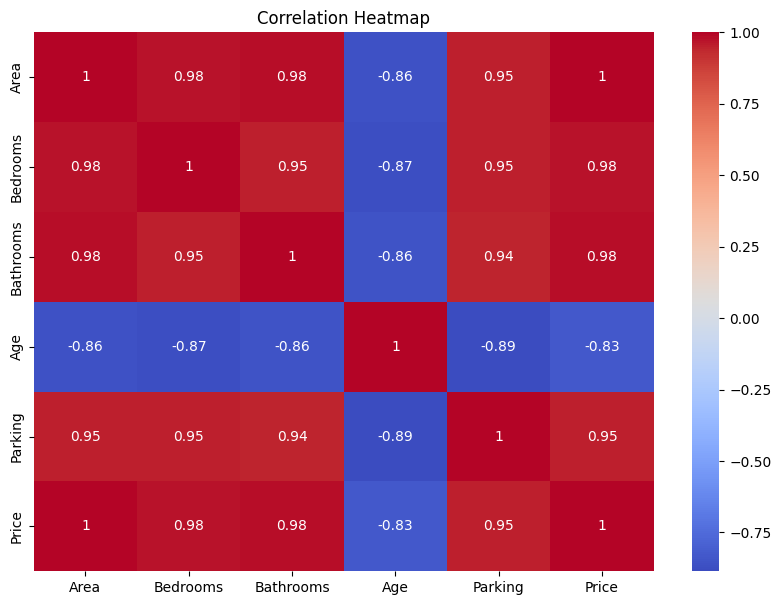

In [65]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap provides a visual representation of the correlations between the features. Area shows a strong positive relationship with price, while the other features also provide information that can help the model predict house prices.

## 9. Feature & Target Selection

In [66]:
X = houses[["Area", "Bedrooms", "Bathrooms", "Age", "Parking"]]

y = houses["Price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20, 5)
y shape: (20,)


### Observation

The five property characteristics are selected as input features, while Price is selected as the target variable.

X contains multiple features, so it is a two-dimensional DataFrame, while y contains a single target variable and is one-dimensional.

## 10. Train-Test Split

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16, 5)
(4, 5)
(16,)
(4,)


### Observation

The dataset is divided into 80% training data and 20% testing data.

The training data is used to teach the model, while the test data is used to evaluate how well the model performs on unseen data.

## 11. Model Building & Training

In [68]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [69]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -2978741.1024331376
Coefficients: [  2541.48962333 445757.53960048 798862.98370479 116880.90909126
 312766.68721808]


### Observation

The Multiple Linear Regression model learns the relationship between the five input features and house price.

Each coefficient represents the estimated change in house price associated with a one-unit change in that feature, while keeping the other features constant.

## 12. Model Prediction

In [70]:
y_pred = model.predict(X_test)

print("Predicted Prices:", y_pred)
print("Actual Prices:", y_test.values)

Predicted Prices: [ 2636689.30135804 15536437.3514994  14074083.96256855  3319106.9073855 ]
Actual Prices: [ 2800000 16000000 14000000  3500000]


### Observation

The predicted prices can be compared with the actual prices from the test dataset to understand how closely the model's predictions match the real values.

## 13. Model Evaluation

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 220462.60058140033
MSE: 69942864460.3273
R² Score: 0.9980389965630483


### Observation

The evaluation metrics help measure how accurately the model predicts house prices.

MAE represents the average absolute prediction error, MSE gives greater weight to larger errors, and the R² score measures how much of the variation in house prices is explained by the model.

## 14. Actual vs Predicted Prices

In [72]:
comparison = pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": y_pred
})

print(comparison)

   Actual_Price  Predicted_Price
0       2800000     2.636689e+06
1      16000000     1.553644e+07
2      14000000     1.407408e+07
3       3500000     3.319107e+06


### Observation

Comparing actual and predicted prices helps identify how close the model's predictions are to the actual house prices in the test dataset.

## 15. Actual vs Predicted Visualization

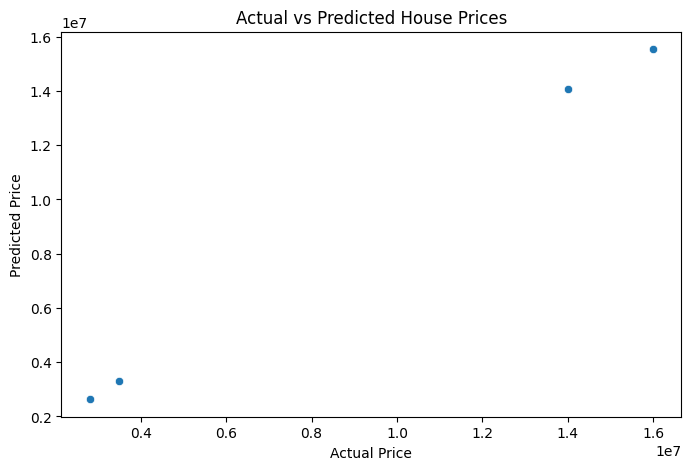

In [73]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

### Observation

The actual versus predicted plot helps visualize the accuracy of the model. Points closer to a straight diagonal relationship indicate that the predicted prices are closer to the actual prices.

## 16. Prediction for a New House

In [74]:
new_house = pd.DataFrame({
    "Area": [2500],
    "Bedrooms": [4],
    "Bathrooms": [3],
    "Age": [5],
    "Parking": [2]
})

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 8764539.985290455


### Observation

The trained model predicts the estimated price of a new house based on its area, number of bedrooms, bathrooms, age, and parking availability.

This prediction is an estimate based on the patterns learned from the available dataset.

## 17. Business Conclusion

The project demonstrates how Multiple Linear Regression can be used to predict house prices using multiple property characteristics such as area, number of bedrooms, number of bathrooms, house age, and parking availability.

The dataset was divided into 80% training data and 20% testing data. The model was trained on the training data and evaluated on unseen test data using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score.

The model achieved an MAE of approximately ₹2.20 lakh, an MSE of approximately ₹69.94 billion, and an R² Score of 0.998. The high R² Score indicates that the model explains approximately 99.8% of the variation in house prices within this dataset.

For a new house with an area of 2,500 sq ft, 4 bedrooms, 3 bathrooms, an age of 5 years, and 2 parking spaces, the model predicted a price of approximately ₹87.65 lakh.

Overall, the results show that Multiple Linear Regression can effectively model the relationship between the selected property features and house prices in this dataset.

However, this dataset is relatively small and artificially created for learning purposes. Real-world house prices can depend on many additional factors such as location, property condition, neighborhood, amenities, market conditions, and economic factors. Therefore, the model should not be used for real-world pricing decisions without a larger and more representative dataset.